In [46]:
# first train/get a pretrianed model and covert it to an array
import torch
import numpy as np
from ultralytics import YOLO
from PIL import Image
import cv2
import matplotlib.pyplot as plt

model = YOLO("yolov5nu.pt")
state_dict = model.model.state_dict()

# convert model
weights = {k.replace(".", "_"): v.cpu().numpy() for k, v in state_dict.items()}

# visualize the weights and structure
for name, array in weights.items():
    print(f"Layer: {name}")
    print(f"  Shape: {array.shape}")
    print(f"  Dtype: {array.dtype}")
    # Print first 5 elements flat
    print(f"  Sample values: {array.flatten()[:5]}")
    print("-" * 40)

Layer: model_0_conv_weight
  Shape: (16, 3, 6, 6)
  Dtype: float32
  Sample values: [ -0.0069771    0.041779  -0.0025826  0.00072384   0.0033131]
----------------------------------------
Layer: model_0_bn_weight
  Shape: (16,)
  Dtype: float32
  Sample values: [     1.9062      2.0273      5.5508       1.041      3.7422]
----------------------------------------
Layer: model_0_bn_bias
  Shape: (16,)
  Dtype: float32
  Sample values: [     1.5957      1.5889      -6.457      4.3125     -5.7539]
----------------------------------------
Layer: model_0_bn_running_mean
  Shape: (16,)
  Dtype: float32
  Sample values: [  -0.019547  -0.0048332    -0.47876     0.13147     0.42725]
----------------------------------------
Layer: model_0_bn_running_var
  Shape: (16,)
  Dtype: float32
  Sample values: [    0.10242    0.079102    0.067993   0.0077629    0.053497]
----------------------------------------
Layer: model_0_bn_num_batches_tracked
  Shape: ()
  Dtype: int64
  Sample values: [1]
----------

## Inference >>>

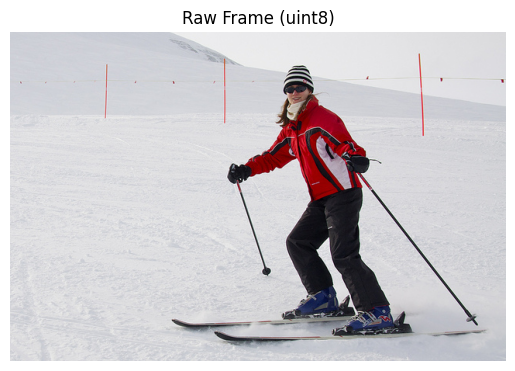

In [47]:
weights = weights
frame = Image.open("/mnt/fileserver/prj/yolo-inference-from-scratch/imgs/000000000785.jpg")
frame = np.array(frame)

# visualize
plt.imshow(frame)  # HWC, RGB
plt.title("Raw Frame (uint8)")
plt.axis("off")
plt.show()

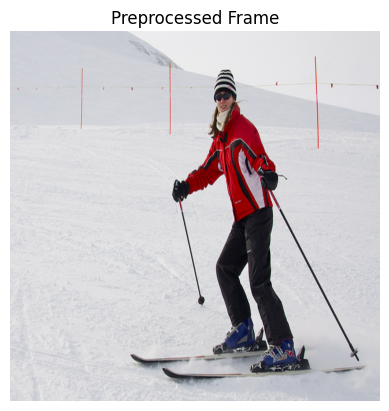

In [48]:
# 1. Pre process img/vid (frame)
# 1.1. downscale
res = "640*640" #320*320

if res == "320*320":
    imsz = (640,640)
else:   # default
    imsz = (640,640)

frame = cv2.resize(frame, imsz)

# 1.2. convert frame to np.arrays unit8->float32,float16,int8
d_type = "fp32"

if d_type == "fp16":
    frame = frame.astype(np.float16)
elif d_type == "int8":
    frame = (frame*255).astype(np.int8)
else: # default
    frame = frame.astype(np.float32)

# 1.3. Normalize to [0,1]
frame = frame/255

# 1.4 Convert from HWC to CHW
frame = np.transpose(frame, (2, 0, 1))

# visualize (convert back to HWC)
frame_to_show = frame.transpose(1, 2, 0)
plt.imshow(frame_to_show)
plt.title("Preprocessed Frame")
plt.axis("off")
plt.show()